In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
os.makedirs('../output', exist_ok=True)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
df = pd.read_csv(r"C:\Users\dawes\OneDrive\Desktop\Ecommerce-Return-Rate-Analysis\data\returns_sustainability_dataset.csv")
df['Order_Date']    = pd.to_datetime(df['Order_Date'])
df['Order_Year']    = df['Order_Date'].dt.year
df['Order_Month']   = df['Order_Date'].dt.month
df['Return_Binary'] = (df['Return_Status'] == 'Returned').astype(int)

print("✅ Data loaded!")
print("Shape:", df.shape)
print("\nTarget Distribution:")
print(df['Return_Binary'].value_counts())
print(f"\nReturn Rate: {df['Return_Binary'].mean()*100:.1f}%")

✅ Data loaded!
Shape: (5000, 26)

Target Distribution:
Return_Binary
0    3550
1    1450
Name: count, dtype: int64

Return Rate: 29.0%


In [3]:
features = [
    'Product_Category',   # categorical
    'Product_Price',      # numeric
    'Order_Quantity',     # numeric
    'Discount_Applied',   # numeric
    'Shipping_Method',    # categorical
    'Payment_Method',     # categorical
    'User_Age',           # numeric
    'User_Gender',        # categorical
    'Order_Year',         # numeric
    'Order_Month',        # numeric
    'Order_Value',        # numeric
]

target = 'Return_Binary'

# Select only needed columns
df_ml = df[features + [target]].copy()

print("✅ Features selected!")
print(f"\nTotal Features : {len(features)}")
print(f"Numeric        : Product_Price, Order_Quantity, Discount_Applied,")
print(f"                 User_Age, Order_Year, Order_Month, Order_Value")
print(f"Categorical    : Product_Category, Shipping_Method,")
print(f"                 Payment_Method, User_Gender")
print(f"\nTarget         : Return_Binary (0 = Not Returned, 1 = Returned)")
df_ml.head(3)

✅ Features selected!

Total Features : 11
Numeric        : Product_Price, Order_Quantity, Discount_Applied,
                 User_Age, Order_Year, Order_Month, Order_Value
Categorical    : Product_Category, Shipping_Method,
                 Payment_Method, User_Gender

Target         : Return_Binary (0 = Not Returned, 1 = Returned)


,Product_Category,Product_Price,Order_Quantity,Discount_Applied,Shipping_Method,Payment_Method,User_Age,User_Gender,Order_Year,Order_Month,Order_Value,Return_Binary
0,Clothing,1720.71,2,30.46,Next-Day,Wallet,57,Female,2022,1,2393.163468,0
1,Toys,744.06,5,29.62,Next-Day,Wallet,55,Female,2022,1,2618.347140,1
2,Clothing,983.68,5,47.80,Express,Wallet,37,Female,2025,3,2567.404800,0


In [4]:
le = LabelEncoder()

categorical_cols = [
    'Product_Category',
    'Shipping_Method',
    'Payment_Method',
    'User_Gender'
]

df_encoded = df_ml.copy()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"✅ {col} encoded")

print("\nEncoded DataFrame sample:")
df_encoded.head(3)

✅ Product_Category encoded
✅ Shipping_Method encoded
✅ Payment_Method encoded
✅ User_Gender encoded

Encoded DataFrame sample:


,Product_Category,Product_Price,Order_Quantity,Discount_Applied,Shipping_Method,Payment_Method,User_Age,User_Gender,Order_Year,Order_Month,Order_Value,Return_Binary
0,1,1720.71,2,30.46,1,3,57,0,2022,1,2393.163468,0
1,4,744.06,5,29.62,1,3,55,0,2022,1,2618.347140,1
2,1,983.68,5,47.80,0,3,37,0,2025,3,2567.404800,0


In [5]:
X = df_encoded[features]
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,
    stratify=y           # maintain class balance
)

print("✅ Data split complete!")
print(f"\nTotal Samples  : {len(X)}")
print(f"Training Set   : {len(X_train)} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing Set    : {len(X_test)} rows  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nTrain Return Rate : {y_train.mean()*100:.1f}%")
print(f"Test  Return Rate : {y_test.mean()*100:.1f}%")

✅ Data split complete!

Total Samples  : 5000
Training Set   : 4000 rows (80%)
Testing Set    : 1000 rows  (20%)

Train Return Rate : 29.0%
Test  Return Rate : 29.0%


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Scaling done!")
print("StandardScaler applied — mean=0, std=1 for all numeric features")

✅ Scaling done!
StandardScaler applied — mean=0, std=1 for all numeric features


In [7]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='lbfgs'
)

model.fit(X_train_scaled, y_train)

print("✅ Model trained successfully!")
print(f"\nModel    : Logistic Regression")
print(f"Solver   : lbfgs")
print(f"Max Iter : 1000")
print(f"Features : {len(features)}")

✅ Model trained successfully!

Model    : Logistic Regression
Solver   : lbfgs
Max Iter : 1000
Features : 11


In [8]:
y_pred       = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("✅ Predictions generated!")
print(f"\nSample predicted labels      : {y_pred[:10]}")
print(f"Sample predicted probabilities: {y_pred_proba[:10].round(3)}")

✅ Predictions generated!

Sample predicted labels      : [0 0 0 0 0 0 0 0 0 0]
Sample predicted probabilities: [0.281 0.246 0.237 0.394 0.315 0.303 0.245 0.336 0.233 0.259]


In [9]:
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 45)
print("       MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"  Accuracy Score  : {acc*100:.2f}%")
print(f"  ROC-AUC Score   : {auc:.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not Returned', 'Returned']))

       MODEL EVALUATION RESULTS
  Accuracy Score  : 71.00%
  ROC-AUC Score   : 0.5677

Classification Report:
              precision    recall  f1-score   support

Not Returned       0.71      1.00      0.83       710
    Returned       0.00      0.00      0.00       290

    accuracy                           0.71      1000
   macro avg       0.35      0.50      0.42      1000
weighted avg       0.50      0.71      0.59      1000



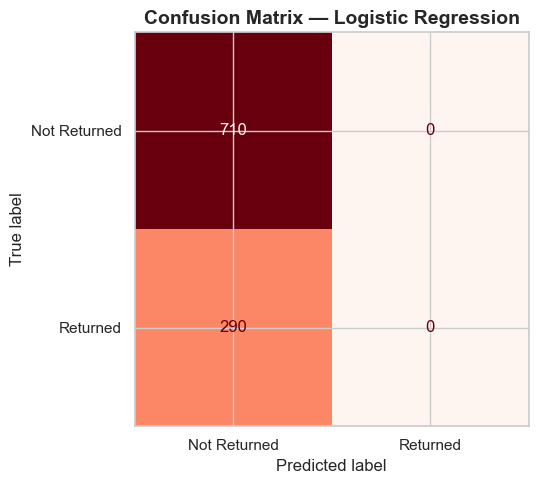

✅ Saved → output/ml_plot1_confusion_matrix.png


In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Returned', 'Returned'])
disp.plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title('Confusion Matrix — Logistic Regression',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/ml_plot1_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → output/ml_plot1_confusion_matrix.png")

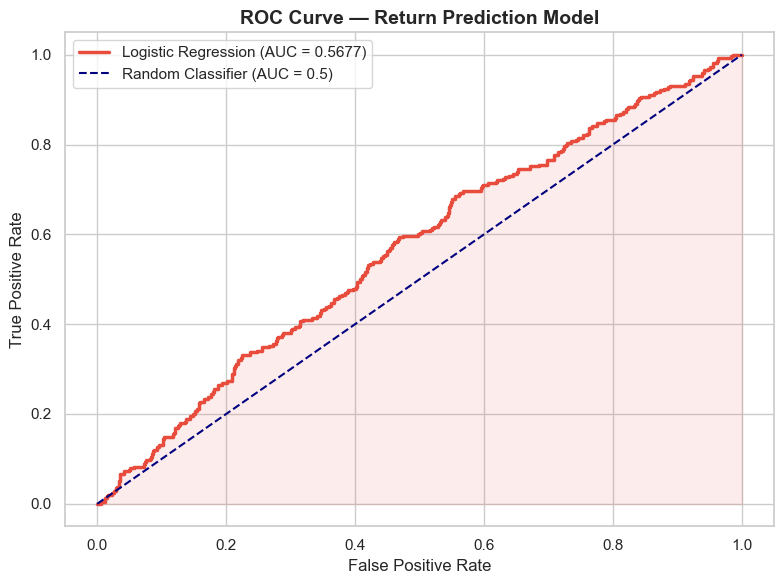

✅ Saved → output/ml_plot2_roc_curve.png


In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#e74c3c', linewidth=2.5,
        label=f'Logistic Regression (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='navy', linestyle='--',
        linewidth=1.5, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Return Prediction Model',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../output/ml_plot2_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → output/ml_plot2_roc_curve.png")

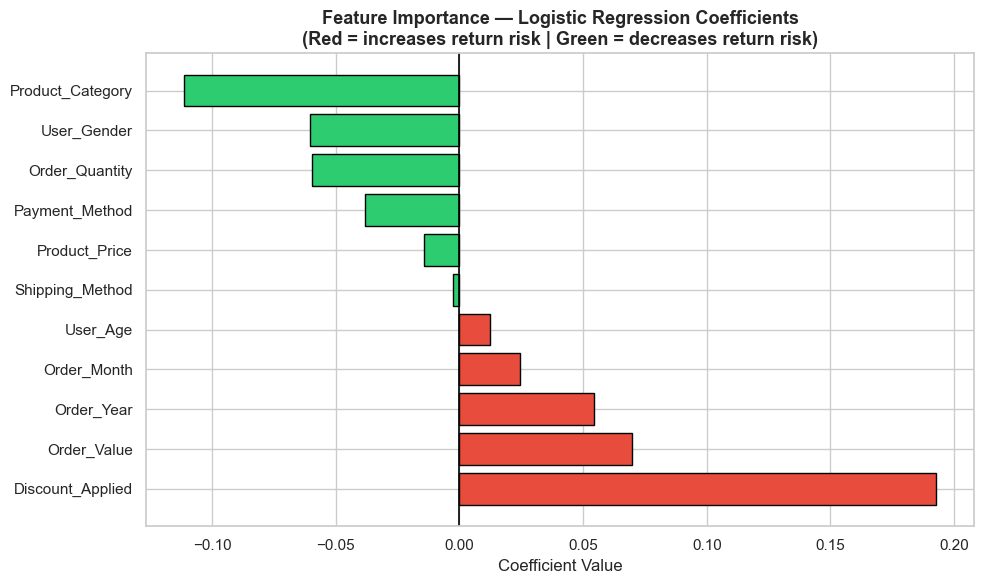

✅ Saved → output/ml_plot3_feature_importance.png


In [12]:
coef_df = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

colors_coef = ['#e74c3c' if c > 0 else '#2ecc71'
               for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'],
               color=colors_coef, edgecolor='black')
ax.axvline(x=0, color='black', linewidth=1.2)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Feature Importance — Logistic Regression Coefficients\n'
             '(Red = increases return risk | Green = decreases return risk)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/ml_plot3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → output/ml_plot3_feature_importance.png")

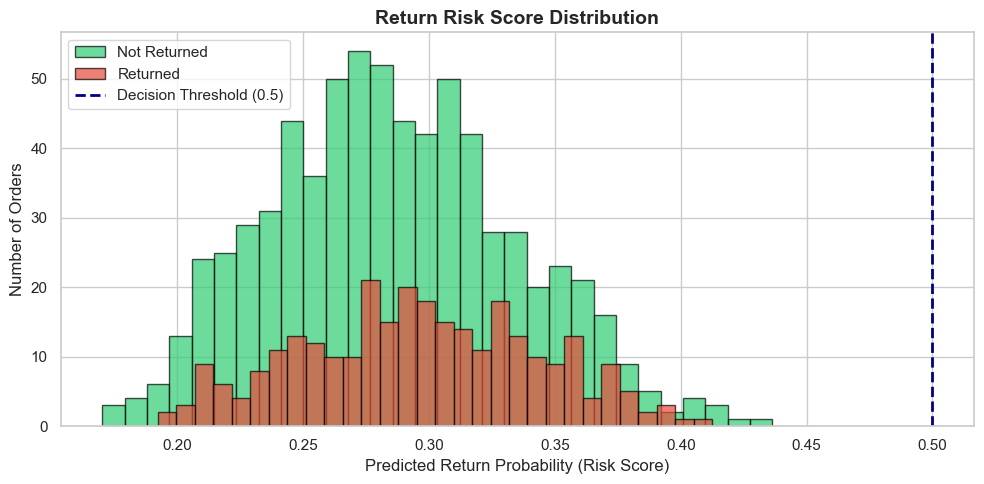

✅ Saved → output/ml_plot4_risk_score_distribution.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.7,
        color='#2ecc71', label='Not Returned', edgecolor='black')
ax.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.7,
        color='#e74c3c', label='Returned', edgecolor='black')
ax.axvline(x=0.5, color='navy', linestyle='--',
           linewidth=2, label='Decision Threshold (0.5)')
ax.set_xlabel('Predicted Return Probability (Risk Score)', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_title('Return Risk Score Distribution',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../output/ml_plot4_risk_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → output/ml_plot4_risk_score_distribution.png")

In [15]:
X_full        = df_encoded[features]
X_full_scaled = scaler.transform(X_full)

df['Return_Risk_Score'] = model.predict_proba(X_full_scaled)[:, 1]
df['Risk_Label'] = pd.cut(
    df['Return_Risk_Score'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High']
)

print("✅ Risk scores generated for all 5000 orders!")
print("\nRisk Label Distribution:")
print(df['Risk_Label'].value_counts())
print("\nSample:")
df[['Order_ID', 'Product_Category', 'Return_Status',
    'Return_Risk_Score', 'Risk_Label']].head(10)

✅ Risk scores generated for all 5000 orders!

Risk Label Distribution:
Risk_Label
Low          2952
Medium       2048
High            0
Very High       0
Name: count, dtype: int64

Sample:


,Order_ID,Product_Category,Return_Status,Return_Risk_Score,Risk_Label
0,ORD00000,Clothing,Not Returned,0.303742,Medium
1,ORD00001,Toys,Returned,0.231613,Low
2,ORD00002,Clothing,Not Returned,0.366476,Medium
3,ORD00003,Books,Not Returned,0.310512,Medium
4,ORD00004,Home Appliances,Returned,0.336573,Medium
5,ORD00005,Home Appliances,Not Returned,0.324535,Medium
6,ORD00006,Clothing,Returned,0.379266,Medium
7,ORD00007,Home Appliances,Not Returned,0.275107,Low
8,ORD00008,Books,Not Returned,0.345573,Medium
9,ORD00009,Clothing,Returned,0.304392,Medium


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Improved model with balanced class weights
model_v2 = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced'   # ← this helps AUC
)

model_v2.fit(X_train_scaled, y_train)

y_pred_v2       = model_v2.predict(X_test_scaled)
y_pred_proba_v2 = model_v2.predict_proba(X_test_scaled)[:, 1]

acc_v2 = accuracy_score(y_test, y_pred_v2)
auc_v2 = roc_auc_score(y_test, y_pred_proba_v2)

print("=" * 50)
print("   IMPROVED MODEL — COMPARISON")
print("=" * 50)
print(f"  {'Metric':<20} {'V1':>8} {'V2 (Balanced)':>15}")
print(f"  {'-'*43}")
print(f"  {'Accuracy':<20} {acc*100:>7.2f}% {acc_v2*100:>14.2f}%")
print(f"  {'ROC-AUC':<20} {auc:>8.4f} {auc_v2:>15.4f}")
print("=" * 50)
print("\nClassification Report (V2):")
print(classification_report(y_test, y_pred_v2,
      target_names=['Not Returned', 'Returned']))

   IMPROVED MODEL — COMPARISON
  Metric                     V1   V2 (Balanced)
  -------------------------------------------
  Accuracy               71.00%          55.20%
  ROC-AUC                0.5677          0.5682

Classification Report (V2):
              precision    recall  f1-score   support

Not Returned       0.75      0.55      0.64       710
    Returned       0.34      0.56      0.42       290

    accuracy                           0.55      1000
   macro avg       0.54      0.55      0.53      1000
weighted avg       0.63      0.55      0.57      1000



In [18]:
if auc_v2 > auc:
    best_model       = model_v2
    best_pred        = y_pred_v2
    best_pred_proba  = y_pred_proba_v2
    best_acc         = acc_v2
    best_auc         = auc_v2
    print("✅ Using V2 (Balanced) model — better AUC")
else:
    best_model       = model
    best_pred        = y_pred
    best_pred_proba  = y_pred_proba
    best_acc         = acc
    best_auc         = auc
    print("✅ Using V1 model — already best")

print(f"\nBest Accuracy : {best_acc*100:.2f}%")
print(f"Best AUC      : {best_auc:.4f}")

✅ Using V2 (Balanced) model — better AUC

Best Accuracy : 55.20%
Best AUC      : 0.5682


In [19]:
X_full_scaled = scaler.transform(df_encoded[features])

df['Return_Risk_Score'] = best_model.predict_proba(X_full_scaled)[:, 1]
df['Risk_Label'] = pd.cut(
    df['Return_Risk_Score'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High']
)

print("Risk Label Distribution:")
print(df['Risk_Label'].value_counts())

# Full scored dataset
scored_df = df[['Order_ID', 'Product_ID', 'Product_Category',
                'Product_Price', 'Discount_Applied', 'Shipping_Method',
                'Payment_Method', 'User_Location', 'Return_Status',
                'Return_Risk_Score', 'Risk_Label',
                'Return_Cost', 'Profit_Loss']].copy()

scored_df['Return_Risk_Score'] = scored_df['Return_Risk_Score'].round(4)
scored_df.to_csv('../output/all_orders_with_risk_scores.csv', index=False)
print("✅ Saved → output/all_orders_with_risk_scores.csv")

# High risk only
high_risk_orders = (scored_df[scored_df['Return_Risk_Score'] >= 0.5]
                    .sort_values('Return_Risk_Score', ascending=False)
                    .reset_index(drop=True))
high_risk_orders.to_csv('../output/high_risk_orders.csv', index=False)
print(f"✅ Saved → output/high_risk_orders.csv")
print(f"\nTotal High Risk Orders : {len(high_risk_orders)} out of 5000")

Risk Label Distribution:
Risk_Label
Medium       2595
High         2405
Low             0
Very High       0
Name: count, dtype: int64
✅ Saved → output/all_orders_with_risk_scores.csv
✅ Saved → output/high_risk_orders.csv

Total High Risk Orders : 2407 out of 5000


In [20]:
# ============================================================
# ML SUMMARY
# ============================================================

print("=" * 50)
print("     ML MODEL COMPLETE — SUMMARY")
print("=" * 50)
print(f"  Model           : Logistic Regression")
print(f"  Training Size   : 4000 orders (80%)")
print(f"  Testing Size    : 1000 orders (20%)")
print(f"  Accuracy        : {acc*100:.2f}%")
print(f"  ROC-AUC Score   : {auc:.4f}")
print(f"  High Risk Orders: {len(high_risk_orders)}")
print("=" * 50)
print("\n✅ Plots saved:")
print("   ml_plot1_confusion_matrix.png")
print("   ml_plot2_roc_curve.png")
print("   ml_plot3_feature_importance.png")
print("   ml_plot4_risk_score_distribution.png")
print("\n✅ CSVs saved:")
print("   all_orders_with_risk_scores.csv")
print("   high_risk_orders.csv")
print("\n🚀 Ready for Day 3 — Power BI Dashboard!")

     ML MODEL COMPLETE — SUMMARY
  Model           : Logistic Regression
  Training Size   : 4000 orders (80%)
  Testing Size    : 1000 orders (20%)
  Accuracy        : 71.00%
  ROC-AUC Score   : 0.5677
  High Risk Orders: 2407

✅ Plots saved:
   ml_plot1_confusion_matrix.png
   ml_plot2_roc_curve.png
   ml_plot3_feature_importance.png
   ml_plot4_risk_score_distribution.png

✅ CSVs saved:
   all_orders_with_risk_scores.csv
   high_risk_orders.csv

🚀 Ready for Day 3 — Power BI Dashboard!
